**LAB : 11**

**Automated Report Generation using Python**

**OBJECTIVES:**

1) To run an automated EDA notebook and generate a comprehensive data analysis report.
2) To analyze dataset characteristics including missing values, distributions, and correlations using automated tools.
3) To extract meaningful insights and visualize patterns for better data-driven decision making.

=== SALES DATA ===
   Product  Sales  Revenue
0   Laptop    120   660000
1    Phone    250   700000
2   Tablet    180   351000
3    Watch    310   263500
4  Earbuds    400   180000

=== KEY METRICS ===
Total Revenue  : Rs. 2154500
Total Units    : 1260
Best Revenue   : Phone
Most Sold      : Earbuds



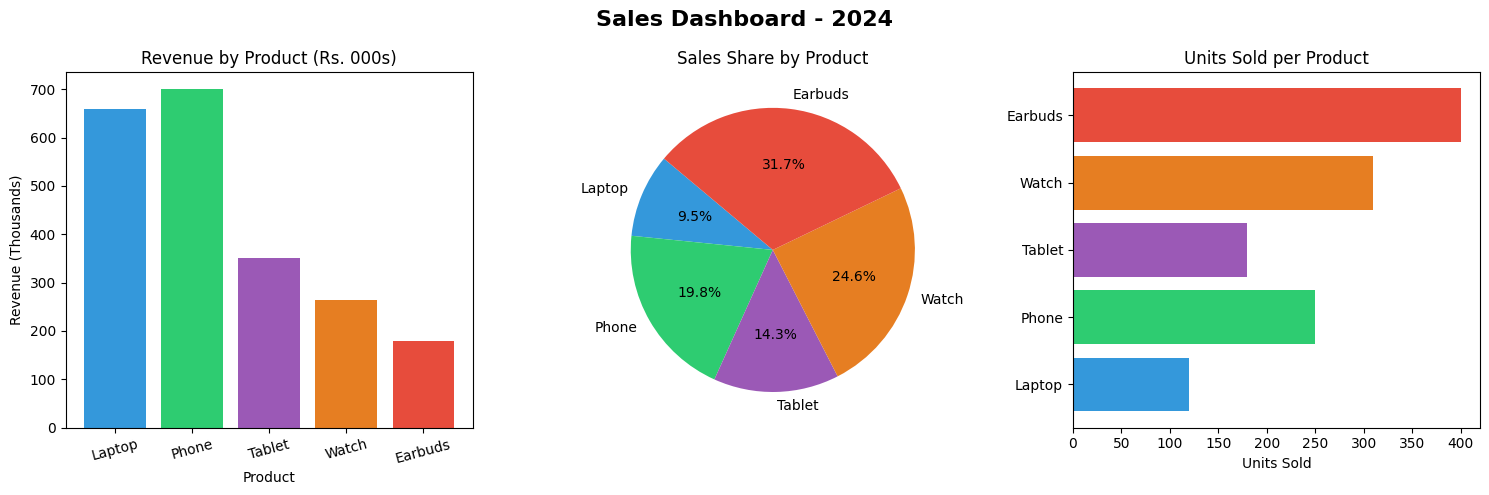

Dashboard image saved as dashboard.png

=== AUTOMATED INSIGHTS ===
Excellent! Revenue crossed Rs. 20 Lakhs.
Phone generated the highest revenue this period.

Report saved as report.html
Open report.html in your browser to view the full report!


In [ ]:
import pandas as pd                     # For data handling and analysis
import matplotlib.pyplot as plt         # For creating charts
from jinja2 import Template             # For generating dynamic HTML reports
from datetime import datetime           # For adding current date/time in report
import base64                           # For embedding image inside HTML


# ------------------------------------------------------------
# STEP 1: CREATE SAMPLE SALES DATA
# ------------------------------------------------------------

# Create a dictionary representing sales data
data = {
    "Product": ["Laptop", "Phone", "Tablet", "Watch", "Earbuds"],
    "Sales":   [120, 250, 180, 310, 400],          # Units sold
    "Revenue": [660000, 700000, 351000, 263500, 180000]  # Revenue in Rs.
}

# Convert dictionary into a pandas DataFrame (table format)
df = pd.DataFrame(data)

# Print data to console
print("=== SALES DATA ===")
print(df)
print()


# ------------------------------------------------------------
# STEP 2: CALCULATE KPIs (Key Performance Indicators)
# ------------------------------------------------------------

# Calculate total revenue (sum of Revenue column)
total_revenue = df["Revenue"].sum()

# Calculate total units sold
total_sales = df["Sales"].sum()

# Find product with highest revenue
best_product = df.loc[df["Revenue"].idxmax(), "Product"]

# Find product with highest units sold
most_sold = df.loc[df["Sales"].idxmax(), "Product"]

# Print KPI results
print("=== KEY METRICS ===")
print("Total Revenue  : Rs.", total_revenue)
print("Total Units    :", total_sales)
print("Best Revenue   :", best_product)
print("Most Sold      :", most_sold)
print()


# ------------------------------------------------------------
# STEP 3: CREATE DASHBOARD CHARTS
# ------------------------------------------------------------

# Create a figure with 3 charts in one row
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Main dashboard title
fig.suptitle("Sales Dashboard - 2024", fontsize=16, fontweight="bold")

# Define custom colors for charts
COLORS = ["#3498DB", "#2ECC71", "#9B59B6", "#E67E22", "#E74C3C"]

# ---- Chart 1: Bar Chart (Revenue by Product) ----
axes[0].bar(df["Product"], df["Revenue"] / 1000, color=COLORS)
axes[0].set_title("Revenue by Product (Rs. 000s)")
axes[0].set_xlabel("Product")
axes[0].set_ylabel("Revenue (Thousands)")
axes[0].tick_params(axis="x", rotation=15)

# ---- Chart 2: Pie Chart (Sales Share) ----
axes[1].pie(
    df["Sales"],
    labels=df["Product"],
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=140
)
axes[1].set_title("Sales Share by Product")

# ---- Chart 3: Horizontal Bar (Units Sold) ----
axes[2].barh(df["Product"], df["Sales"], color=COLORS)
axes[2].set_title("Units Sold per Product")
axes[2].set_xlabel("Units Sold")

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save the dashboard as an image file
plt.savefig("dashboard.png", dpi=120, bbox_inches="tight")

# Display chart on screen
plt.show()

print("Dashboard image saved as dashboard.png")
print()


# ------------------------------------------------------------
# STEP 4: AUTO-GENERATE BUSINESS INSIGHTS
# ------------------------------------------------------------

# Generate revenue comment based on performance
if total_revenue > 2000000:
    comment = "Excellent! Revenue crossed Rs. 20 Lakhs."
elif total_revenue > 1000000:
    comment = "Good performance. Revenue is above Rs. 10 Lakhs."
else:
    comment = "Revenue is below Rs. 10 Lakhs. Review your strategy."

# Comment about best revenue product
top_comment = best_product + " generated the highest revenue this period."

# Print auto insights
print("=== AUTOMATED INSIGHTS ===")
print(comment)
print(top_comment)
print()


# ------------------------------------------------------------
# STEP 5: CONVERT IMAGE TO BASE64 (Embed in HTML)
# ------------------------------------------------------------

# Open image in binary mode
with open("dashboard.png", "rb") as img_file:
    # Convert image into base64 string
    img_base64 = base64.b64encode(img_file.read()).decode("utf-8")


# ------------------------------------------------------------
# STEP 6: CREATE HTML TEMPLATE
# ------------------------------------------------------------

# Create dynamic HTML template using Jinja2
html_template = Template("""
<!DOCTYPE html>
<html>
<head>
  <title>Sales Report 2024</title>
</head>
<body style="font-family: Arial; background:#f5f5f5; padding:30px;">

<h1 style="text-align:center;">Sales Analytics Report - 2024</h1>
<p style="text-align:center; color:gray;">
Generated on: {{ date }}
</p>

<h2>Key Metrics</h2>
<ul>
  <li><b>Total Revenue:</b> Rs. {{ total_revenue }}</li>
  <li><b>Total Units Sold:</b> {{ total_sales }}</li>
  <li><b>Best Revenue Product:</b> {{ best_product }}</li>
  <li><b>Most Units Sold:</b> {{ most_sold }}</li>
</ul>

<h2>Dashboard Charts</h2>
<img src="data:image/png;base64,{{ chart }}" width="800">

<h2>Automated Insights</h2>
<p>{{ comment }}</p>
<p>{{ top_comment }}</p>

<h2>Product Summary Table</h2>
<table border="1" cellpadding="8" cellspacing="0">
<tr>
  <th>Product</th>
  <th>Units Sold</th>
  <th>Revenue (Rs.)</th>
  <th>Revenue Share (%)</th>
</tr>

{% for row in table_rows %}
<tr>
  <td>{{ row.product }}</td>
  <td>{{ row.sales }}</td>
  <td>{{ row.revenue }}</td>
  <td>{{ row.share }}</td>
</tr>
{% endfor %}

</table>

</body>
</html>
""")


# ------------------------------------------------------------
# STEP 7: PREPARE TABLE DATA
# ------------------------------------------------------------

table_rows = []

# Loop through DataFrame rows
for _, row in df.iterrows():
    table_rows.append({
        "product": row["Product"],
        "sales": row["Sales"],
        "revenue": f"{int(row['Revenue']):,}",
        "share": round(row["Revenue"] / total_revenue * 100, 1)
    })


# ------------------------------------------------------------
# STEP 8: RENDER FINAL HTML REPORT
# ------------------------------------------------------------

# Replace template variables with actual values
html_output = html_template.render(
    date=datetime.now().strftime("%d %B %Y, %I:%M %p"),
    total_revenue=f"{total_revenue:,}",
    total_sales=total_sales,
    best_product=best_product,
    most_sold=most_sold,
    chart=img_base64,
    comment=comment,
    top_comment=top_comment,
    table_rows=table_rows
)


# ------------------------------------------------------------
# STEP 9: SAVE REPORT AS HTML FILE
# ------------------------------------------------------------

with open("report.html", "w", encoding="utf-8") as f:
    f.write(html_output)

print("Report saved as report.html")
print("Open report.html in your browser to view the full report!")
